In [1]:
from astropy.table import Table, vstack
from astroquery.gaia import Gaia
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [ ]:
reportable = pd.read_csv('(#path to#))reportable.csv', index_col='Unnamed: 0')
reportable['bp-rp'] = reportable['phot_bp_mean_mag']-reportable['phot_rp_mean_mag']
reportable['abs_g_mag'] = reportable['phot_g_mean_mag'] - 5*np.log10(1000/reportable['parallax']) + 5
reportable['frac'] = reportable['sigma']/reportable['period']

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
cold = reportable[reportable['bp-rp'] >= 0.6]

nonoscillators = cold[cold['abs_g_mag'] > (2*cold['bp-rp'] - 4)]

subgiants = nonoscillators[nonoscillators['abs_g_mag'] < (1.4*nonoscillators['bp-rp']+2.8)]
ms = nonoscillators[nonoscillators['abs_g_mag'] >= (1.4*nonoscillators['bp-rp']+2.8)]

In [18]:
dr3_ids_ms = ms['dr3_source_id'].to_list()
dr3_ids_sg = subgiants['dr3_source_id'].to_list()
query_sg = f"SELECT gsource.source_id AS dr3_source_id, gsource.mass_flame, gsource.mass_flame_lower, gsource.mass_flame_upper FROM gaiadr3.astrophysical_parameters AS gsource WHERE gsource.source_id IN ({','.join(map(str, dr3_ids_sg))}) "
query_ms = f"SELECT gsource.source_id AS dr3_source_id, gsource.mass_flame, gsource.mass_flame_lower, gsource.mass_flame_upper FROM gaiadr3.astrophysical_parameters AS gsource WHERE gsource.source_id IN ({','.join(map(str, dr3_ids_ms))}) "

In [19]:
job1 = Gaia.launch_job(query_sg)
job2 = Gaia.launch_job(query_ms)

result_table_sg = job1.get_results().to_pandas().drop_duplicates(subset='dr3_source_id')
result_table_ms = job2.get_results().to_pandas().drop_duplicates(subset='dr3_source_id')

In [20]:
merged_sg = pd.merge(nonoscillators, result_table_sg, on='dr3_source_id', how='inner')
merged_ms = pd.merge(nonoscillators, result_table_ms, on='dr3_source_id', how='inner')

hasmass_sg = merged_sg.dropna(axis='rows', subset='mass_flame', how='any')
hasmass_ms = merged_ms.dropna(axis='rows', subset='mass_flame', how='any')

In [24]:
hasmass_sg['tau_conv'] = 10**(1.16 - (1.49*np.log10(hasmass_sg['mass_flame'])) - (0.54 * (np.log10(hasmass_sg['mass_flame']))**2))
hasmass_sg['rossby'] = hasmass_sg['period']/hasmass_sg['tau_conv']

hasmass_ms['tau_conv'] = 10**(1.16 - (1.49*np.log10(hasmass_ms['mass_flame'])) - (0.54 * (np.log10(hasmass_ms['mass_flame']))**2))
hasmass_ms['rossby'] = hasmass_ms['period']/hasmass_ms['tau_conv']

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_27901/4074451150.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hasmass_sg['tau_conv'] = 10**(1.16 - (1.49*np.log10(hasmass_sg['mass_flame'])) - (0.54 * (np.log10(hasmass_sg['mass_flame']))**2))
/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_27901/4074451150.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hasmass_sg['rossby'] = hasmass_sg['period']/hasmass_sg['tau_conv']
/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel

In [25]:
solar_prot_min = 25.67
solar_prot_max = 33.60
solar_tauconv = 10**1.16
solar_rossby_mi = solar_prot_min/solar_tauconv
solar_rossby_ma = solar_prot_max/solar_tauconv

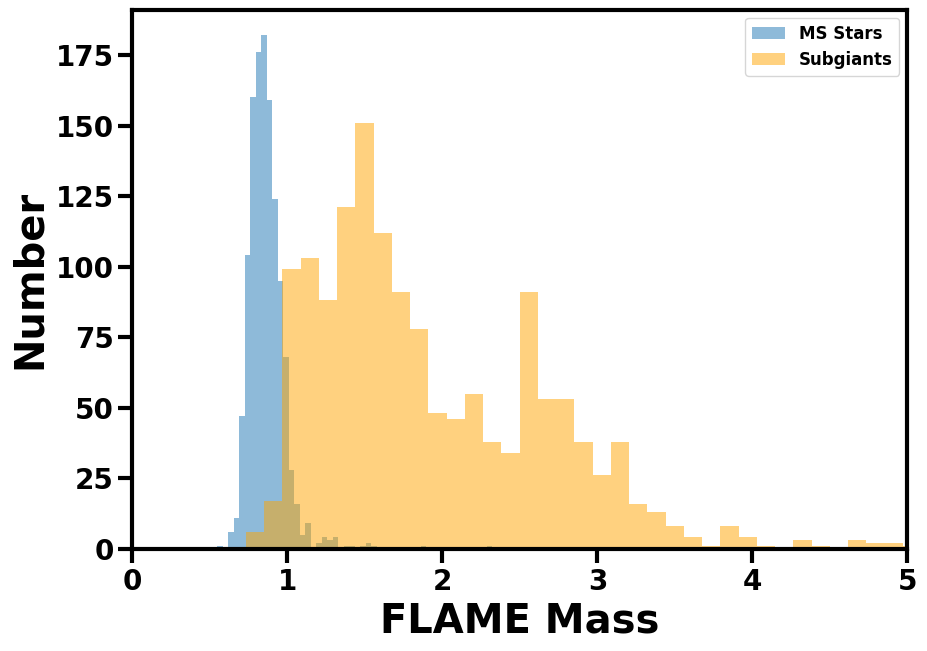

In [26]:
fig, ax = plt.subplots(1, figsize=(10, 7))
h = ax.hist(hasmass_ms['mass_flame'], bins=50, alpha=0.5, label='MS Stars')
h2 = ax.hist(hasmass_sg['mass_flame'], bins=50, color='orange', alpha=0.5, label="Subgiants")
ax.set(xlabel='FLAME Mass', ylabel='Number', xlim=(0, 5))
ax.legend(fontsize=12)

# there appears to be a bimodality in the subgiants, lets cut them by mass

In [47]:
lowmass = hasmass_sg[hasmass_sg['mass_flame'] < 2.1] #946 total
bigmass = hasmass_sg[hasmass_sg['mass_flame'] >= 2.1] #514 total
hasmass_ms #1212 total

,asas_sn_id,period,sigma,dr3_source_id,dr2_source_id,edr3_source_id,KIC,tic_id,ra_rad,dec_rad,...,in_training,in_xgboost_training,simulation_number,bp-rp,frac,mass_flame,mass_flame_lower,mass_flame_upper,tau_conv,rossby
0,386547629657,12.751509,1.731133,54393153759525760,54393153759525760,54393153759525760,NaN,303413224.0,0.877295,0.277616,...,no,False,NaN,1.335890,0.135759,0.742767,0.702444,0.783362,22.050743,0.578280
2,377957516391,25.628582,6.260658,76300510625993344,76300510625993344,76300510625993344,NaN,408628165.0,0.625380,0.269119,...,no,False,NaN,0.812903,0.244284,0.968366,0.928355,1.008378,15.159876,1.690554
3,231929278462,11.425999,2.547062,42907174260408192,42907174260408192,42907174260408192,NaN,434159022.0,0.984422,0.271010,...,no,False,NaN,1.252684,0.222918,0.904069,0.863648,0.945285,16.758045,0.681822
4,317828523563,14.764905,3.136345,54204072119374336,54204072119374336,54204072119374336,NaN,303503431.0,0.893835,0.268248,...,no,False,NaN,1.036768,0.212419,0.823878,0.783822,0.867571,19.122375,0.772127
5,231929338040,19.377203,2.098126,40033875500034944,40033875500034944,40033875500034944,NaN,242984254.0,1.039207,0.266018,...,no,False,NaN,1.367738,0.108278,0.779690,0.739334,0.820083,20.640888,0.938778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,163209497809,22.375385,5.533757,66712322557468288,66712322557468288,66712322557468288,NaN,NaN,0.996342,0.420791,...,no,False,NaN,1.195462,0.247314,0.875504,0.829024,0.919441,17.548300,1.275074
1995,163209411391,8.119721,1.903768,66480944080770176,66480944080770176,66480944080770176,NaN,346540537.0,1.009156,0.415849,...,no,True,NaN,1.245935,0.234462,0.801412,0.761402,0.841416,19.872990,0.408581
1996,171799014967,11.736392,1.738049,104759719843431424,104759719843431424,104759719843431424,NaN,28361640.0,0.524809,0.419267,...,no,False,NaN,1.080412,0.148091,0.905531,0.864413,0.947134,16.719034,0.701978
1997,171799249901,12.186375,2.393723,293221819640116864,293221819640116864,293221819640116864,NaN,16995762.0,0.351504,0.421878,...,no,False,NaN,1.311642,0.196426,0.754228,0.714228,0.794228,21.598230,0.564230


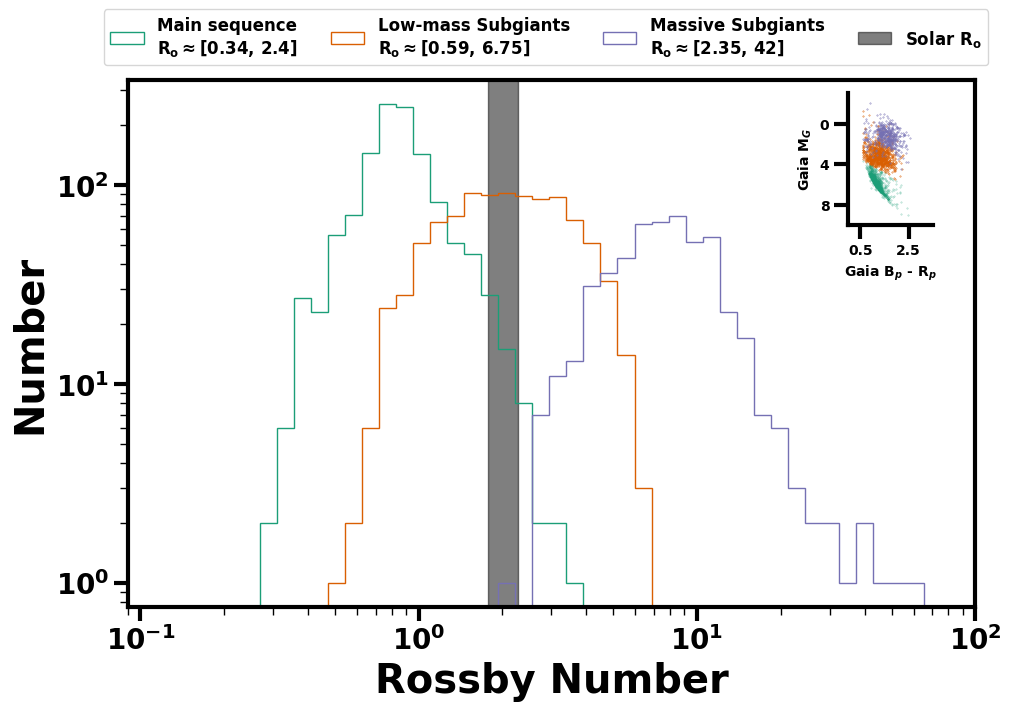

In [71]:
fig, ax = plt.subplots(1, figsize=(10, 7), layout='constrained')


h = ax.hist(hasmass_ms['rossby'], bins=np.logspace(-1, 2, 50), color='#1B9E77', label="Main sequence\n" +  r'R$_{\rm{o}}$$\approx$[0.34, 2.4]', histtype='step', rasterized=True, log=True)
h2 = ax.hist(lowmass['rossby'], bins=np.logspace(-1, 2, 50), color='#D95F02', label="Low-mass Subgiants\n"+r'R$_{\rm{o}}$$\approx$[0.59, 6.75]', histtype='step', rasterized=True, log=True)
h3 = ax.hist(bigmass['rossby'], bins=np.logspace(-1, 2, 50), color="#7570B3", label="Massive Subgiants\n"+r'R$_{\rm{o}}$$\approx$[2.35, 42]',  histtype='step', rasterized=True, log=True)
x=np.arange(solar_rossby_mi, solar_rossby_ma, 0.05)
bottom, top = ax.get_ylim()
ax.fill_between(x, bottom, top, alpha=0.5, color='k', label=r'Solar R$_{\rm{o}}$', rasterized=True)
ax.set_yscale('log')
ax.set_xscale('log')

ax.set(xlabel='Rossby Number', ylabel='Number', ylim=(bottom, top), xlim=(0.09, 100))
ax.legend(ncols=4, fontsize=12, bbox_to_anchor=(0.025, 1.1, 1.0, 0.05))
axin1 = ax.inset_axes([0.85, 0.725, 0.1, 0.25])

axin1.set(xlim=(0, 3.5), ylim=(10, -3), xlabel='Gaia B$_\rm{p}$ - R$_p$', ylabel='Gaia M$_G$')
im1 = axin1.scatter('bp-rp', 'abs_g_mag', data=lowmass, s=.1, c ="#D95F02", rasterized=True)
im1 = axin1.scatter('bp-rp', 'abs_g_mag', data=bigmass,  s=.1, c="#7570B3", rasterized=True)
im1 = axin1.scatter('bp-rp', 'abs_g_mag', data=hasmass_ms, s=.1, c='#1B9E77', alpha=0.5, rasterized=True)
axin1.set_xlabel('Gaia B$_p$ - R$_p$', fontsize=10)
axin1.set_ylabel(f'Gaia M$_G$', fontsize=10)
axin1.set_xticks(ticks=(0.5, 2.5), labels=[0.5, 2.5], fontsize=10)
axin1.set_yticks(ticks=[0, 4, 8], labels=[0, 4, 8], fontsize=10)
axin1.set(facecolor=(0.0, 0.0, 0.0, 0.0))
axin1.spines['top'].set_visible(False)
axin1.spines['right'].set_visible(False)
axin1.tick_params(right=False, top=False, labelright=False, labeltop=False)
fig.savefig('rossby_num.pdf', dpi=300)